In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib
import tensorflow as tf

from tensorflow.keras import layers, models

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams["font.family"] = "Malgun Gothic"          # 한글 폰트 지정
plt.rcParams["axes.unicode_minus"] = False             # 마이너스 부호 깨짐 방지


np.random.seed(42)
tf.random.set_seed(42)

In [16]:
# 데이터 가져오기 (32x32 이미지 크기)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# cnn 입력 형태에 맞게 채녈 차원을 reshape
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

In [17]:
# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

In [18]:
class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog",
               "Frog", "Horse", "Ship", "Truck"]

In [19]:
# 모델 정의
model = models.Sequential([
    # 첫번쨰 CNN Layer
    layers.Conv2D(32, (3,3), padding="same", input_shape=(32,32,3)),   # 컬러 이미지 입력
    layers.BatchNormalization(),                                       # 학습 안정화 및 수행속도 향상
    layers.Activation("relu"),
    layers.MaxPooling2D(2,2),                                          # 특징 추출해서 크기를 감소
    layers.Dropout(0.5),

    # 두번째 CNN Layer
    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.5),
    
    # 세번째 CNN Layer
    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2,2),

    # Fully Connected Layer
    layers.Flatten(),                           # 2D --> 1D 벡터로 변환
    layers.Dense(256),                          # 256개의 뉴런으로 학습
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(10, activation="softmax")      # 10개 클래스에 대한 확률 출력
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
# 모델 컴파일
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
# 모델 학습
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - accuracy: 0.4023 - loss: 1.6926 - val_accuracy: 0.1972 - val_loss: 3.4216
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.5156 - loss: 1.3399 - val_accuracy: 0.1896 - val_loss: 3.4904
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.5684 - loss: 1.1996 - val_accuracy: 0.3810 - val_loss: 2.0438
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.6035 - loss: 1.1111 - val_accuracy: 0.4641 - val_loss: 1.6883
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.6327 - loss: 1.0391 - val_accuracy: 0.5218 - val_loss: 1.4860
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.6522 - loss: 0.9849 - val_accuracy: 0.5293 - val_loss: 1.4537
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.6663 - loss: 0.9440 - val_accuracy: 0.5521 - val_loss: 1.3715
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.6797 - loss: 0.9074 - 

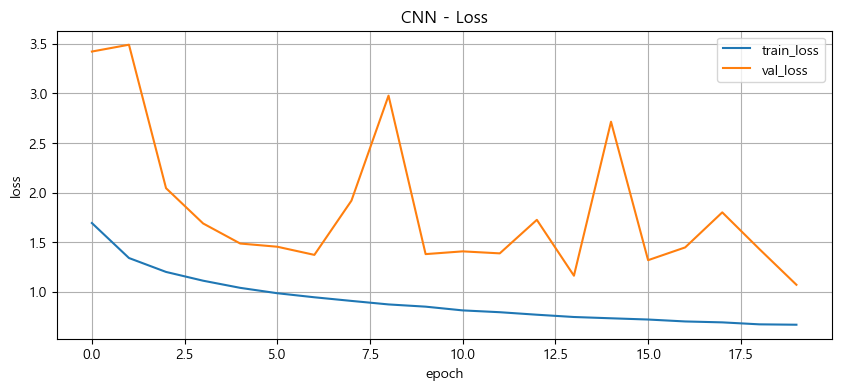

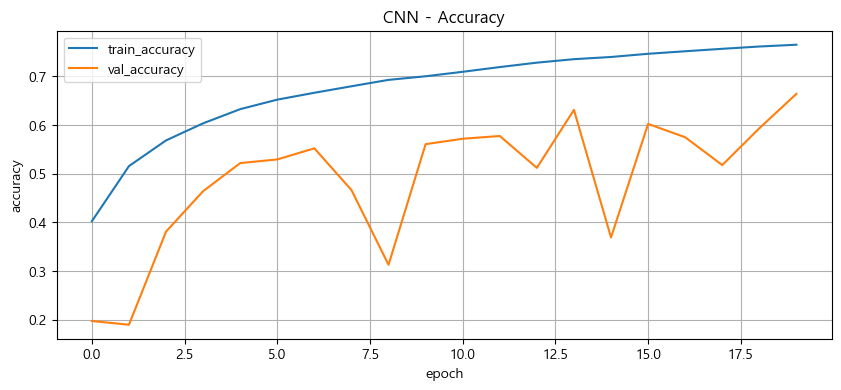

In [22]:
# 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("CNN - Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("CNN - Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# 예측 확률 계산

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


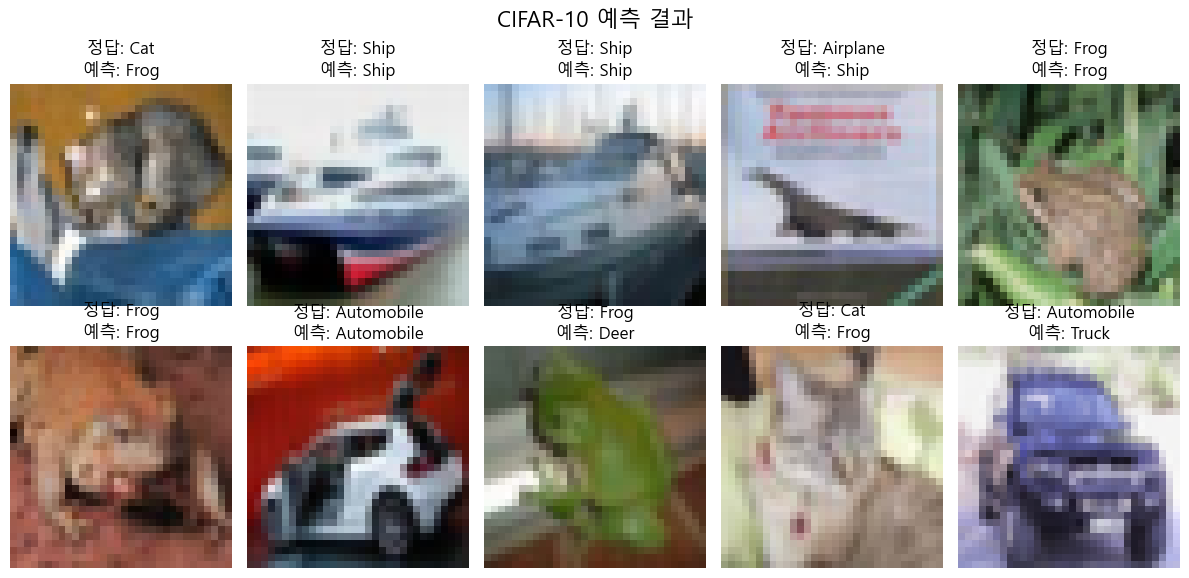

In [25]:
# 10개 이미지 예측 시각화
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    plt.title(f"정답: {class_names[y_test[i]]}\n예측: {class_names[y_pred[i]]}")
    plt.axis("off")
plt.suptitle("CIFAR-10 예측 결과", fontsize=16)
plt.tight_layout()
plt.show()

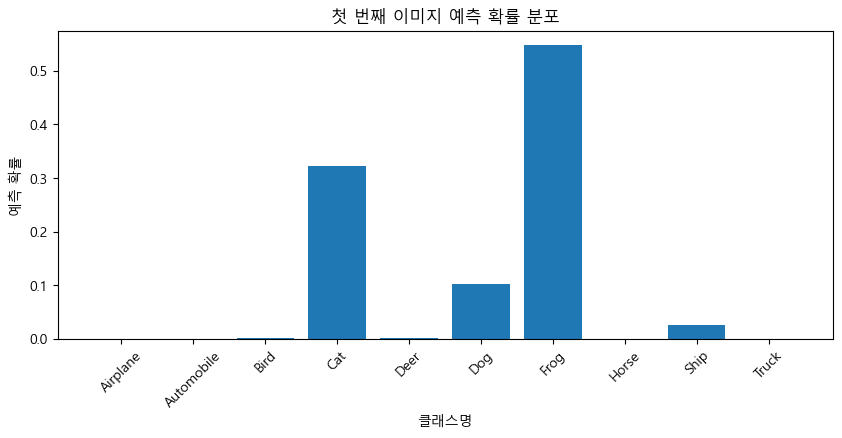

In [27]:
# 개별 이미지 클래스별 예측 확률 확인
plt.figure(figsize=(10, 4))
plt.bar(range(10), y_prob[0])
plt.xticks(range(10), class_names, rotation=45)
plt.xlabel("클래스명")
plt.ylabel("예측 확률")
plt.title("첫 번째 이미지 예측 확률 분포")
plt.show()